# 2024 Spoken Wiki attentional word recognition task results

### Analysis is for main diotic experiment
### Models run on all combinations of stimuli
___

In [19]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle
import importlib 
import IPython.display as ipd
%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats 
# from matplotlib.ticker import FormatStrFormatter

import src.util_process_prolific as up 
from tqdm import tqdm
importlib.reload(up)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

## Set font to helvetica 
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']


In [20]:
# outfig_dest = Path('CCN_2024/figures')
# outfig_dest.mkdir(parents=True, exist_ok=True)





### Import human data

In [21]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
path_to_expmt_stim = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("cocktail_party_word_recognition_all_conds/data/*.json"))

len(human_fnames)

428

## Process Human Results

In [22]:
results_df.columns

Index(['success', 'timeout', 'failed_images', 'failed_audio', 'failed_video',
       'trial_type', 'trial_index', 'time_elapsed', 'internal_node_id',
       'output_filename', 'id_random', 'id_study', 'id_subject', 'id_session',
       'id_version', 'hc_passed', 'view_history', 'rt', 'response',
       'question_order', 'stimulus', 'stim_type', 'hc_answer', 'hc_correct',
       'over_ear_hf', 'hearing_loss', 'response_str', 'catch_trial',
       'correct_response', 'trial_num', 'correct', 'n_correct', 'n_incorrect',
       'snr', 'condition'],
      dtype='object')

In [23]:
results_df[results_df.trial_type == 'survey-multi-choice'].response

2    {'country': 'Prefer not to answer', 'language'...
3    {'headphones': 'In-ear headphones or earbuds',...
2    {'country': 'USA', 'language': 'English', 'gen...
3    {'headphones': 'In-ear headphones or earbuds',...
2    {'country': 'USA', 'language': 'English', 'gen...
                           ...                        
3    {'headphones': 'Over-the-ear headphones', 'con...
2    {'country': 'UK', 'language': 'English', 'gend...
3    {'headphones': 'Over-the-ear headphones', 'con...
2    {'country': 'UK', 'language': 'English', 'gend...
3    {'headphones': 'Over-the-ear headphones', 'con...
Name: response, Length: 560, dtype: object

0      Female
1      Female
2      Female
3      Female
4      Female
        ...  
601     Other
602     Other
603     Other
604     Other
605     Other
Name: gender, Length: 132164, dtype: object

In [24]:
## Get all subject data into one df for analysis

dfs = []
for fname in human_fnames:
    try:
        dfs.append(up.get_part_df_swc(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)

## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]
## Filter self reported hearing loss 
results_df = results_df[results_df.hearing_loss == False]
# results_df = results_df[results_df.over_ear_hf == True]

## Add snr and condition names as columns - unpack from file code in file names 

# get cond name map
map_path = path_to_expmt_stim / 'human_attn_expmt_cond_map.pkl' 
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)
stim_cond_map = {f"condition_{k:02}": v for k,v in stim_cond_map.items()}

# add as columns 
results_df['snr'], results_df['condition'] = zip(*results_df['stimulus'].apply(lambda x: up.get_stim_snr_and_cond(x, stim_cond_map=stim_cond_map)))

# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str].copy()
trial_results.rename(columns={"condition":"raw_condition"}, inplace=True)

# Convert condition names to  readable format 
test_condition_dict = {'music':"background_musdb18hq",
                       "babble":"background_cv08talkerbabble",
                       "stationary": "background_issnstationary",
                       "natural scene": "background_ieeeaaspcasa",
                       "clean": "SILENCE"}
# 1-talker conds preserved in replace below

condition_map = {v:k for k,v in test_condition_dict.items()}
trial_results['condition'] = trial_results['raw_condition'].replace(condition_map)

# screen based on completion 
total_trials = 196
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').condition.count() == total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]
# Add accuracy 
trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')

# add shortened stim name field 
trial_results['stim_name'] = trial_results['stimulus'].str.split('/').str[-1].str.split('.').str[0]

# drop coluns in trial_results that are all nans 
trial_results = trial_results.dropna(axis=1, how='all')

Unterminated string starting at: line 1 column 84194 (char 84193)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_all_conds/data/subj_6658b1491e88ec15902d5301.json
Unterminated string starting at: line 1 column 192613 (char 192612)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_all_conds/data/subj_6174b049932ee98236563b51.json
Unterminated string starting at: line 1 column 72207 (char 72206)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_all_conds/data/subj_65dc99d0191a135ab835bf69.json
Unterminated string starting at: line 1 column 324626 (char 324625)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_all_conds/data/subj_5c0430c71a20110001e9b05a.json
Expecting ',' delimiter: line 1 column 204794 (char 204793)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_all_conds/data/subj_666883e7cd549b6798159085.json
Unterminated string starting at: line 1 column 60213

In [ ]:
# catch_trial_particiapnt_performance
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()

print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 11/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response.isna())]
analysis_df = analysis_df.dropna(axis=1, how='all').dropna(axis=0, how='all')
# analysis_df.groupby('id_subject').condition.count()

N total participants  208
N good participants  195


In [46]:
### Get quick demographics 
demog_fields = results_df[results_df.id_subject.isin(good_participants)]
demogs = demog_fields.groupby('id_subject').first()
print("Gender data")
print(demogs.gender.value_counts())
print("Age data")
demogs['age'] = [int(age) if age != '' else np.nan for age in demogs.age ]
print(f"Min: {demogs.age.min()} Max: {demogs.age.max()} Median: {demogs.age.median()}")

Gender data
Female                  98
Male                    92
Other                    4
Prefer not to answer     1
Name: gender, dtype: int64
Age data
Min: 18.0 Max: 71.0 Median: 33.0


ValueError: invalid literal for int() with base 10: ''


#### Add re-scored performance based on entries included in excerpt transcripts  

In [6]:
### Make map from cv dictionary ixs to experiment word ixs 

## import cv maps
import pickle
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


## import experiment word map
human_exp_word_key = pickle.load( open(path_to_expmt_stim / "human_attn_expmt_word_key.pkl", "rb" )) 
exp_word_2_class = {v:k for k,v in human_exp_word_key.items()}



In [10]:
manifests.word.nunique()

488

In [5]:
## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifests to trial_results where trial_results.stimulus == manifests.base_str

manifests = pd.read_pickle(path_to_expmt_stim / "human_cue_target_distractor_df_w_meta_transcripts_w_f0.pdpkl")
# add columns for word int and stim name to map back to participant data 
manifests['word_fname_int'] = manifests['word'].replace(exp_word_2_class)
manifests['stim_name'] = manifests[['gender', 'word_fname_int']].apply(lambda row: f"{row.gender[0]}_{row.word_fname_int:03d}", axis=1)

cols_to_merge = ['stim_name',
                 'gender',
                 'word',
                 'target_f0',
                 'english_distractor_f0',
                 'mandarin_distractor_f0',
                 'dutch_distractor_f0',
                 'target_transcripts',
                 'same_sex_distractor_1_transcripts',
                 'diff_sex_distractor_1_transcripts',
                 "same_sex_dist_1_word",
                 "diff_sex_dist_1_word"
]

analysis_df = pd.merge(analysis_df,
                        manifests[cols_to_merge],
                                    left_on='stim_name', right_on='stim_name', how='left')
analysis_df['confusions'] = (analysis_df.response == analysis_df.same_sex_dist_1_word).astype('int')
analysis_df['accuracy'] = (analysis_df.response == analysis_df.word).astype('int')


# add adjusted accuracy and confusions 
pred_words = analysis_df.response.values
target_words = analysis_df.word.values
target_transcripts = analysis_df.target_transcripts.values
same_sex_distractor_words = analysis_df.same_sex_dist_1_word.values
diff_sex_distractor_words = analysis_df.diff_sex_dist_1_word.values
same_sex_distractor_transcripts = analysis_df.same_sex_distractor_1_transcripts.values
diff_sex_distractor_transcripts = analysis_df.diff_sex_distractor_1_transcripts.values


adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                            if not isinstance(target_transcript, float) else np.nan
                            for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                            ])

adjusted_confs = np.array([int(pred_word in same_sex_transcript or pred_word in diff_sex_transcript or pred_word == same_sex_word or pred_word == diff_sex_word)
                            if not (isinstance(same_sex_transcript, float) and isinstance(diff_sex_transcript, float)) else np.nan
                            for pred_word, same_sex_word, diff_sex_word, same_sex_transcript, diff_sex_transcript in zip(pred_words, same_sex_distractor_words, diff_sex_distractor_words,  same_sex_distractor_transcripts, diff_sex_distractor_transcripts)
                            ])

analysis_df['adjusted_accuracy'] = adjusted_acc
analysis_df['adjusted_confusions'] = adjusted_confs

## Remap 1-talker distractor names accordingly 

analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'sex_cond'] = analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'condition'].str.split('-').str[-1].str.title()
analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'dist_lang'] = analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'condition'].str.split('-').str[-2].str.title()

def remap_1_distractor_str(cond_str):
    if 'english' in cond_str:
        return '1-talker'
    if 'mandarin' in cond_str:
        return "Mandarin distractor"
    if 'dutch' in cond_str:
        return "Dutch distractor"

analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'condition'] = analysis_df.loc[analysis_df.condition.str.contains('1-talker'), 'condition'].apply(remap_1_distractor_str)
analysis_df = analysis_df[analysis_df.condition != 'catch_trial']



NameError: name 'analysis_df' is not defined

In [8]:
to_check = analysis_df[analysis_df.condition!="catch_trial"]
(to_check.adjusted_accuracy >= to_check.accuracy).all()

True

In [9]:
analysis_df.condition.unique()

array(['stationary', 'Mandarin distractor', 'natural scene', 'clean',
       'Dutch distractor', '1-talker', 'babble', '2-talker', '4-talker',
       'music'], dtype=object)

In [10]:
##########################
# Make df for f0 analysis 
##########################

# drop unwanted conditions
f0_analysis_df = analysis_df[analysis_df.condition.isin([ "1-talker", 'Mandarin distractor', 'Dutch distractor', 'clean'])].copy()

# cut and remove language-specific f0 columns - just make distractor f0 
f0_analysis_df.loc[f0_analysis_df.dist_lang == 'English', 'distractor_f0'] = f0_analysis_df.loc[f0_analysis_df.dist_lang == 'English', 'english_distractor_f0'].values
f0_analysis_df.loc[f0_analysis_df.dist_lang == 'Mandarin', 'distractor_f0'] = f0_analysis_df.loc[f0_analysis_df.dist_lang == 'Mandarin', 'mandarin_distractor_f0'].values
f0_analysis_df.loc[f0_analysis_df.dist_lang == 'Dutch', 'distractor_f0'] = f0_analysis_df.loc[f0_analysis_df.dist_lang == 'Dutch', 'dutch_distractor_f0'].values

f0_analysis_df["abs_f0_diff"] = np.abs(f0_analysis_df.target_f0 - f0_analysis_df.distractor_f0)
f0_analysis_df["percent_f0_diff"] = f0_analysis_df.distractor_f0 / f0_analysis_df.target_f0 
def get_f0_ratio(row):
    return max(row.target_f0, row.distractor_f0) / min(row.target_f0, row.distractor_f0)
f0_analysis_df["f0_ratio"] = f0_analysis_df.apply(get_f0_ratio, axis=1)

# # rename condition to background condition
f0_analysis_df = f0_analysis_df.rename(columns={"condition": "background_condition"})
f0_analysis_df = f0_analysis_df.dropna(axis=1,  how = 'all')
# get columns with trial in their name
cols_to_drop = [col for col in f0_analysis_df.columns if 'trial' in col ]
# drop prolific meta columns
f0_analysis_df = f0_analysis_df.drop(columns=cols_to_drop).reset_index(drop=True)


In [11]:
# get trial data excluding catch trials 


part_summary_df = (analysis_df.groupby(["snr", 'id_subject', "condition"])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())

part_summary_df['snr'] = part_summary_df['snr'].replace(np.inf, 6)
part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)
part_summary_df['snr'] = part_summary_df['snr'].astype('int')
# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


In [12]:
## Summarize participant data for aggregate plotting


summary_df = part_summary_df.groupby(['snr', 'condition']).agg({'correct_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count'],
                                                             'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
summary_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']


## Load Model Results 

In [13]:
## import class maps
import pickle
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}

### Get conditions 
cond_map = pickle.load( open(path_to_expmt_stim / "human_attn_expmt_cond_map.pkl", "rb" )) 
conds = set([cond for cond,snr in cond_map.values()])

test_cond_to_human = {v:k for k,v in test_condition_dict.items()}
cond_remap = {}
for cond in conds:
    if cond in test_cond_to_human:
        cond_remap[cond] = test_cond_to_human[cond]
    else:
        cond_remap[cond] = cond 
cond_remap['natural scene'] = 'natural scene'


In [14]:
cond_remap

{'SILENCE': 'clean',
 'background_cv08talkerbabble': 'babble',
 '1-talker-english-different': '1-talker-english-different',
 '4-talker': '4-talker',
 'background_ieeeaaspcasa': 'natural scene',
 '1-talker-english-same': '1-talker-english-same',
 'background_issnstationary': 'stationary',
 '1-talker-mandarin-same': '1-talker-mandarin-same',
 '1-talker-mandarin-different': '1-talker-mandarin-different',
 'background_musdb18hq': 'music',
 '2-talker': '2-talker',
 '1-talker-dutch-same': '1-talker-dutch-same',
 '1-talker-dutch-different': '1-talker-dutch-different',
 'natural scene': 'natural scene'}

In [15]:
!ls swc_2024_eval_full_stim/

word_task_conventional_layer_order
word_task_early_only_v09
word_task_half_co_loc_v08_gender_bal_4M_sanity
word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout
word_task_half_co_loc_v09_50Hz_cutoff
word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout
word_task_late_only_v09
word_task_v08_control_no_attn
word_task_v09_4MGB_ln_first_arch_1
word_task_v09_4MGB_ln_first_arch_2
word_task_v09_4MGB_ln_first_arch_4
word_task_v09_4MGB_ln_first_arch_6
word_task_v09_4MGB_ln_first_arch_7
word_task_v09_4MGB_ln_first_arch_8
word_task_v09_4MGB_ln_first_arch_9
word_task_v09_control_no_attn
word_task_v09_cue_loc_task
word_task_v09_per_kernel_gains


In [16]:

model_names = ["word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout",
                # "word_task_v08_control_no_attn",
                # "word_task_v09_control_no_attn",
                # "word_task_early_only_v09",
                # "word_task_late_only_v09",
                # "word_task_half_co_loc_v09_50Hz_cutoff",
                # "word_task_conventional_layer_order"
                ]# "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned"]

# get names for arch_search models 
arch_search_models = [path.stem for path in Path('swc_2024_eval_full_stim/').glob('*arch_*')]
model_names.extend(arch_search_models)

model_name_dict = {
                   'word_task_v08_control_no_attn': 'Baseline CNN',
                   'word_task_v09_control_no_attn': 'Baseline CNN',
                   'word_task_early_only_v09': 'Early-only',
                   'word_task_late_only_v09': 'Late-only',



                #    "word_task_gender_balanced_fc_1024_v08": "Gender Balanced large fc v08",
                #    "word_task_half_co_loc_v08_gender_bal": "Gender Balanced v08",
                #    "word_task_half_co_loc_v08_gender_bal_4M": "Gender Balanced v08 4M",
                #    "word_task_half_co_loc_v08_gender_bal_4M_orig": "50% co-located v08 4M",
                #    "word_task_half_co_loc_v08_gender_bal_4M_sanity": "50% co-located GB v08 4M",
                #    "word_task_deep_fc_1024_v08": "Deeper Architecture",
                #    "word_task_half_co_locate_deep_fc_1024_v08": "Deep Arch. 50% co-located",
                #    "word_task_half_co_locate_deep_fc_1024_v08_old": "Deep Arch. 50% co. old ckpt",
                #    "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned": "learned no cue trials",
                #    "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout": "Feature-gain Model"
                   "word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout": "Feature-gain Model",
                   "word_task_conventional_layer_order": "Conventional Layer Order",
                   "word_task_half_co_loc_v09_50Hz_cutoff": "50Hz Cutoff Model"
                  }




all_model_results = []
all_model_f0_results = []

background_conditions = summary_df.background_condition.unique() 
str_to_cond = {v:k for k,v in test_condition_dict.items()}

## preselect manifest columns 
cols_to_merge = [
                #  'stim_name',
                 'gender',
                 'word',
                 'word_int',
                 'target_f0',
                 'english_distractor_f0',
                 'mandarin_distractor_f0',
                 'dutch_distractor_f0',
                 'target_transcripts',
                 'same_sex_distractor_1_transcripts',
                 'diff_sex_distractor_1_transcripts',
                 "same_sex_dist_1_word",
                 "diff_sex_dist_1_word"

]

manifests['word_int'] = manifests.word.replace(cv_word_2_class)
model_manifest = manifests[cols_to_merge].sort_values(['gender', 'word']).copy()
model_manifest['df_index'] = model_manifest.index

# update gt manifests to match readable format 
for model_name in model_names:
    print(model_name)
    output_paths = list(Path(f'swc_2024_eval_full_stim/{model_name}').glob('*.csv'))
    print(len(output_paths))
    results_dfs = []

    for path in output_paths:
        # print(path)
        try:
            df = pd.read_csv(path)
            # reformat dict
            df['model'] = path.parent.name
            #parts of name 
            parts = path.stem.split(path.parent.name)[-1].split('_')   
            # if 'stim_tag' in df.columns:
            #     # rename 
            #     df.rename(columns={'stim_tag':'stim_name'}, inplace=True)
            # use re to split path.stem after model name and before <int>dB 
            df['background_condition'] = [v for v in cond_remap.values() if "_".join(v.split(' ')) in path.stem][0]
            if 'clean' in path.stem:
                df['background_condition'] = 'clean'
                df['snr'] =  'inf' # really np.inf, 6 for plotting 
            else:
                df['snr'] = int(re.search('(-?\d+)dB', path.stem).group(0).strip('dB'))

            df['test_index'] = df.index
            df = pd.merge(df,
                model_manifest,
                            left_on=["test_index", "true_word_int"], right_on=["df_index", "word_int"])

            results_dfs.append(df)
        except Exception as e:
            # print(e)
            continue

    model_results = pd.concat(results_dfs, axis=0, ignore_index=True)
    if model_name in model_name_dict:
        model_str = model_name_dict[model_name]
    else:
        model_str = model_name

    model_results['group'] = model_str
    ## Load in model vocab 
    model_results['pred_word'] = model_results['pred_word_int'].replace(cv_class_2_word)
    model_results['true_word'] = model_results['true_word_int'].replace(cv_class_2_word)


    # Add 1-talker condition metadata to model results

    # add confusions 
    model_results['confusions'] = (model_results.pred_word == model_results.same_sex_dist_1_word).astype('int')

    # add adjusted accuracy and confusions 
    pred_words = model_results.pred_word.values
    target_words = model_results.word.values
    target_transcripts = model_results.target_transcripts.values
    same_sex_distractor_words = model_results.same_sex_dist_1_word.values
    diff_sex_distractor_words = model_results.same_sex_dist_1_word.values
    same_sex_distractor_transcripts = model_results.same_sex_distractor_1_transcripts.values
    diff_sex_distractor_transcripts = model_results.diff_sex_distractor_1_transcripts.values


    adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
                                if not isinstance(target_transcript, float) else np.nan
                                for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
                                ])

    adjusted_confs = np.array([int(pred_word in same_sex_transcript or pred_word in diff_sex_transcript or pred_word == same_sex_word or pred_word == diff_sex_word)
                                if not (isinstance(same_sex_transcript, float) and isinstance(diff_sex_transcript, float)) else np.nan
                                for pred_word, same_sex_word, diff_sex_word, same_sex_transcript, diff_sex_transcript in zip(pred_words, same_sex_distractor_words, diff_sex_distractor_words,  same_sex_distractor_transcripts, diff_sex_distractor_transcripts)
                                ])
    
    model_results['adjusted_accuracy'] = adjusted_acc
    model_results['adjusted_confusions'] = adjusted_confs
    model_results.loc[model_results.background_condition.str.contains('1-talker'), 'sex_cond'] = model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'].str.split('-').str[-1].str.title()
    model_results.loc[model_results.background_condition.str.contains('1-talker'), 'dist_lang'] = model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'].str.split('-').str[-2].str.title()
    model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'] = model_results.loc[model_results.background_condition.str.contains('1-talker'), 'background_condition'].apply(remap_1_distractor_str)

    
    all_model_results.append(model_results)


    model_f0_df = model_results[model_results.background_condition.isin([ "1-talker", 'Mandarin distractor', 'Dutch distractor', 'clean'])].copy()
    model_f0_df.loc[model_f0_df.dist_lang == 'English', 'distractor_f0'] = model_f0_df.loc[model_f0_df.dist_lang == 'English', 'english_distractor_f0'].values
    model_f0_df.loc[model_f0_df.dist_lang == 'Mandarin', 'distractor_f0'] = model_f0_df.loc[model_f0_df.dist_lang == 'Mandarin', 'mandarin_distractor_f0'].values
    model_f0_df.loc[model_f0_df.dist_lang == 'Dutch', 'distractor_f0'] = model_f0_df.loc[model_f0_df.dist_lang == 'Dutch', 'dutch_distractor_f0'].values
    model_f0_df["abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
    model_f0_df["percent_f0_diff"] = model_f0_df.distractor_f0 / model_f0_df.target_f0 
    model_f0_df["f0_ratio"] = model_f0_df.apply(get_f0_ratio, axis=1)
    model_f0_df.loc[:, "abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
    model_f0_df.loc[:, "percent_f0_diff"] = model_f0_df.distractor_f0 / model_f0_df.target_f0 
    all_model_f0_results.append(model_f0_df)

all_model_results = pd.concat(all_model_results, axis=0, ignore_index=True)
all_model_f0_results = pd.concat(all_model_f0_results, axis=0, ignore_index=True)

word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout
97
word_task_v09_4MGB_ln_first_arch_1
61
word_task_v09_4MGB_ln_first_arch_2
61
word_task_v09_4MGB_ln_first_arch_4
61
word_task_v09_4MGB_ln_first_arch_6
61
word_task_v09_4MGB_ln_first_arch_7
61
word_task_v09_4MGB_ln_first_arch_8
61
word_task_v09_4MGB_ln_first_arch_9
61


In [17]:
# Adjusted accuracy should always greater than or equal to accuracy
(all_model_results['adjusted_accuracy'] >= all_model_results['accuracy']).all() 

True

In [18]:
all_model_results.group.unique()

array(['Feature-gain Model', 'word_task_v09_4MGB_ln_first_arch_1',
       'word_task_v09_4MGB_ln_first_arch_2',
       'word_task_v09_4MGB_ln_first_arch_4',
       'word_task_v09_4MGB_ln_first_arch_6',
       'word_task_v09_4MGB_ln_first_arch_7',
       'word_task_v09_4MGB_ln_first_arch_8',
       'word_task_v09_4MGB_ln_first_arch_9'], dtype=object)

In [19]:
N = int(summary_df.N.unique().item())

summary_df['group'] = f'Humans (N={N})'
# model_results['group'] = model_results['group']
# all_model_results = all_model_results[all_model_results.snr > -12]
# combine model and participant results ignore missing columns
combined_results = pd.concat([summary_df, all_model_results], axis=0, ignore_index=True)

In [20]:
combined_results.loc[combined_results.snr == np.inf, 'snr'] = 6
combined_results.loc[combined_results.snr == 'inf', 'snr'] = 6
combined_results.snr = combined_results.snr.astype('int')

combined_results['background_condition'].rename({"stationary":"noise"}, inplace=True)
# combined_results = combined_results[combined_results.snr > -12]
combined_results.loc[combined_results.background_condition == "stationary", 'background_condition'] = "noise"


In [21]:
model_list = combined_results.group.unique()

In [22]:
model_list

array(['Humans (N=195)', 'Feature-gain Model',
       'word_task_v09_4MGB_ln_first_arch_1',
       'word_task_v09_4MGB_ln_first_arch_2',
       'word_task_v09_4MGB_ln_first_arch_4',
       'word_task_v09_4MGB_ln_first_arch_6',
       'word_task_v09_4MGB_ln_first_arch_7',
       'word_task_v09_4MGB_ln_first_arch_8',
       'word_task_v09_4MGB_ln_first_arch_9'], dtype=object)

# Main analysis of Model averages vs Humans 

In [23]:
model_results.columns

Index(['pred_word_int', 'true_word_int', 'accuracy', 'model',
       'background_condition', 'snr', 'test_index', 'gender', 'word',
       'word_int', 'target_f0', 'english_distractor_f0',
       'mandarin_distractor_f0', 'dutch_distractor_f0', 'target_transcripts',
       'same_sex_distractor_1_transcripts',
       'diff_sex_distractor_1_transcripts', 'same_sex_dist_1_word',
       'diff_sex_dist_1_word', 'df_index', 'group', 'pred_word', 'true_word',
       'confusions', 'adjusted_accuracy', 'adjusted_confusions', 'sex_cond',
       'dist_lang'],
      dtype='object')

In [24]:
### Merge all feature based models into one group

wanted_models = ['Feature-gain Model', 'word_task_v09_4MGB_ln_first_arch_1',
       # "Conventional Layer Order",
       'word_task_v09_4MGB_ln_first_arch_2',
       'word_task_v09_4MGB_ln_first_arch_4',
       'word_task_v09_4MGB_ln_first_arch_6',
       'word_task_v09_4MGB_ln_first_arch_7',
       'word_task_v09_4MGB_ln_first_arch_8',
       'word_task_v09_4MGB_ln_first_arch_9']

models_to_summary = all_model_results[all_model_results.group.isin(wanted_models)].copy()

## Summarize participant data for aggregate plotting
# get trial data excluding catch trials 


models_summary_df = (models_to_summary.groupby(["snr", 'group', "background_condition"])
                     .agg({'accuracy':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())

models_summary_df['snr'] = models_summary_df['snr'].replace(np.inf, 6)
models_summary_df['snr'] =  models_summary_df['snr'].replace("inf", 6)
models_summary_df['snr'] = models_summary_df['snr'].astype('int')
# flatten multiindex 
models_summary_df.columns = ['_'.join(col).strip() for col in models_summary_df.columns.values]
# remove trailing underscore
models_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in models_summary_df.columns.values]


fba_summary_df = models_summary_df.groupby(['snr', 'background_condition']).agg({'accuracy_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count'],
                                                             'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
fba_summary_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']
fba_summary_df['group'] = 'Feature-gain Model'

## Save Human and model results for offline use 

In [25]:
## Save pre-combined model results - will be used for bootstrap
out_dir = Path("final_results_dir")
out_dir.mkdir(parents=True, exist_ok=True)

# summary_df.to_pickle(out_dir / "summary_2024_SWC_diotic_participant_results.pdpkl")
# models_summary_df.to_pickle(out_dir / "summary_2024_SWC_diotic_model_results.pdpkl")

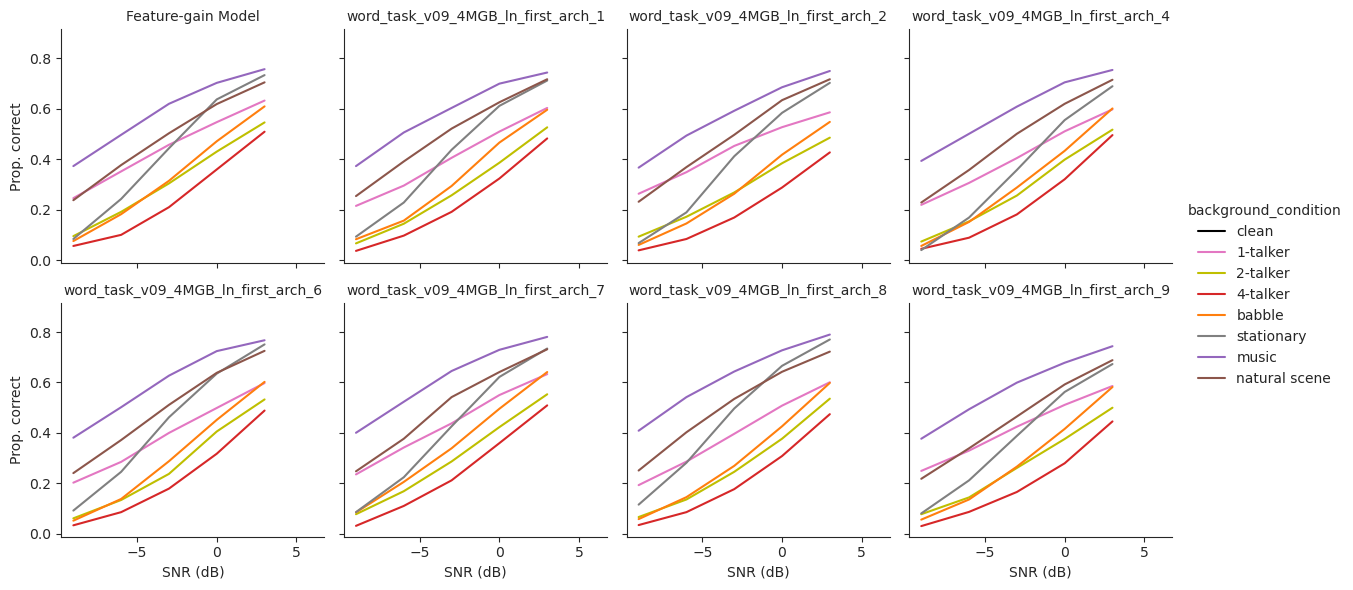

In [26]:
sns.set_style('ticks')

# hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble',  'Dutch distractor', 'Mandarin distractor', 'noise', 'music', 'natural scene']
hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble',  'stationary',  'music', 'natural scene']
palette={}
palette['clean'] = 'k'
palette['1-talker'] = 'tab:pink'
palette['2-talker'] = 'y'
palette['babble'] = 'tab:orange'
palette['4-talker'] = 'tab:red'
palette['stationary'] = 'grey'
palette['music'] = 'tab:purple'
palette['natural scene'] = 'tab:brown'

g = sns.relplot(data=models_summary_df, x='snr', y='adjusted_accuracy_mean', col='group', col_wrap=4, kind='line', hue='background_condition', height=3, palette=palette, hue_order=hue_order)
g.set_axis_labels("SNR (dB)", "Prop. correct")
g.set_titles("{col_name}")

## Summarize models and plot w participants

In [29]:
## merge with human data 
N = int(summary_df.N.unique().item())

summary_df['group'] = f'Humans (N={N})'
# model_results['group'] = model_results['group']
# all_model_results = all_model_results[all_model_results.snr > -12]
# combine model and participant results ignore missing columns
human_fba_results = pd.concat([summary_df, fba_summary_df], axis=0, ignore_index=True)

human_fba_results.loc[human_fba_results.snr == np.inf, 'snr'] = 6
human_fba_results.loc[human_fba_results.snr == 'inf', 'snr'] = 6
human_fba_results.snr = human_fba_results.snr.astype('int')

human_fba_results['background_condition'].rename({"stationary":"noise"}, inplace=True)
# human_fba_results = human_fba_results[human_fba_results.snr > -12]
human_fba_results.loc[human_fba_results.background_condition == "stationary", 'background_condition'] = "noise"


In [32]:
human_fba_results[(human_fba_results.group.str.contains('Humans')) & (human_fba_results.snr == 0) & (human_fba_results.background_condition == '2-talker')]

,snr,background_condition,accuracy,acc_std_error,confusions,conf_std_error,N,adjusted_accuracy,adj_acc_std_error,adjusted_confusions,adj_conf_std_error,group
28,0,2-talker,0.389744,0.020887,0.032051,0.006001,195,0.500427,0.021332,0.094872,0.011051,Humans (N=195)


In [34]:
0.500427 - (2*0.021332	)

0.457763

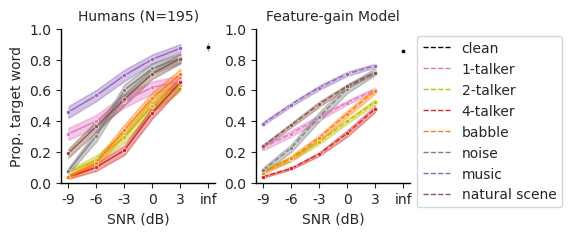

In [28]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = human_fba_results[(~human_fba_results.background_condition.isin(["catch_trial", 'audioset']))  ] # & ~(human_fba_results.group == 'Baseline CNN')
sns.set_style('ticks')



# hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble',  'Dutch distractor', 'Mandarin distractor', 'noise', 'music', 'natural scene']
hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble',  'noise',  'music', 'natural scene']
palette={}
palette['clean'] = 'k'
palette['1-talker'] = 'tab:pink'
palette['2-talker'] = 'y'
palette['babble'] = 'tab:orange'
palette['4-talker'] = 'tab:red'
palette['noise'] = 'grey'
palette['music'] = 'tab:purple'
palette['natural scene'] = 'tab:brown'
# palette['Mandarin distractor'] = 'teal'

fontsize=10
tick_fontsize = 10
# fontsize = 10

models = human_fba_results.group.unique()

n_models = len(models)

aspect = 2
fig, axs = plt.subplots(1, 2, figsize=((aspect) * 2.5 , aspect ))
err_band_alpha = 0.4
# add markers to relplot
# models = [f'Humans (N={N})', 'Feature-gain Model', ]
x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'

yticks = np.linspace(0,1,6).round(1)
ratio = 1.0 
line_thickness = 1
sem_order = 2

for ax, model in zip(axs, models):
    sns.lineplot(data=to_plot[to_plot.group == model],  x='snr', y='adjusted_accuracy', hue='background_condition', hue_order=hue_order,
                  palette=palette, ax=ax,
                  errorbar=('se', sem_order), err_style='band', err_kws={'alpha':err_band_alpha},
                  marker='.', 
                 )
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        if not group in hue_order:
            continue
        # plot the errorbar with the correct color for each group 
        selected['adj_acc_std_error'] = selected['adj_acc_std_error'] * sem_order
        # ax.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette[group], marker=None, ls='none' )
        # add errorbar as fill_between 
        ax.fill_between(selected['snr'], selected['adjusted_accuracy'] - selected['adj_acc_std_error'],
                         selected['adjusted_accuracy'] + selected['adj_acc_std_error'], color=palette[group], alpha=err_band_alpha)

    ax.set_xlabel("SNR (dB)", fontsize=fontsize)
    ax.set_title(model, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_yticks(np.linspace(0,1,6).round(1))
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        if model != models[0]:
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

# remove legend
# g._legend.remove()
sns.despine()
# turn off axs[0] legend 
for ix in range(n_models-1):
    axs[ix].legend().remove()

axs[0].set_ylabel("Prop. target word", fontsize=fontsize)
for ix in range(1, n_models):
    axs[ix].set_ylabel("", fontsize=fontsize)

# move axs[1] legend 
axs[-1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize)


# set space between pannels 
plt.subplots_adjust(wspace=0.01)
# 
# plt.tight_layout()
# plt.savefig(outfig_dest/'human_v_model_acc_for_poster.pdf', transparent=True, bbox_inches='tight')

# adjust w space 

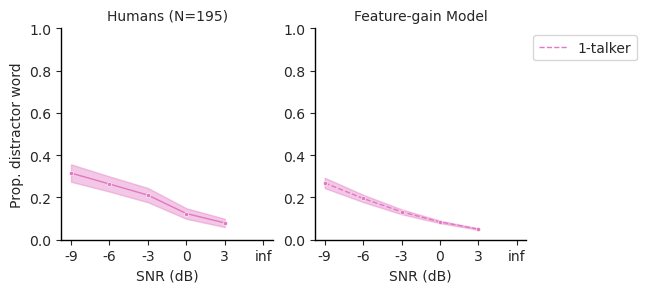

In [29]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = human_fba_results[(~human_fba_results.background_condition.isin(["catch_trial", 'audioset'])) ]
sns.set_style('ticks')



# hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble',  'Dutch distractor', 'Mandarin distractor', 'noise', 'music', 'natural scene']
hue_order = ['1-talker']
palette={}
palette['clean'] = 'k'
palette['1-talker'] = 'tab:pink'
palette['2-talker'] = 'y'
palette['babble'] = 'tab:orange'
palette['4-talker'] = 'tab:red'
palette['noise'] = 'grey'
palette['music'] = 'tab:purple'
palette['natural scene'] = 'tab:brown'
# palette['Mandarin distractor'] = 'teal'

fontsize=10
tick_fontsize = 10
# fontsize = 10

aspect = 3
n_models = len(models)
fig, axs = plt.subplots(1, n_models, figsize=((n_models) * aspect , aspect ))

err_band_alpha = 0.4
# add markers to relplot
models = human_fba_results.group.unique()

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'

yticks = np.linspace(0,1,6).round(1)
ratio = 1.0 
line_thickness = 1

for ax, model in zip(axs, models):
    ax.plot(x_tick_locs, np.ones(len(x_tick_locs)) * 0.5, 'w', alpha=0.5, label=None)

    sns.lineplot(data=to_plot[to_plot.group == model],  x='snr', y='adjusted_confusions', hue='background_condition', hue_order=hue_order,
                  palette=palette, ax=ax,
                  errorbar=('se', 2), err_style='band', err_kws={'alpha':err_band_alpha},
                  marker='.', 
                 )
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        if not group in hue_order:
            continue
        # plot the errorbar with the correct color for each group 
        selected['adj_conf_std_error'] = selected['adj_conf_std_error'] * 2 
        # ax.errorbar(data=selected, x="snr", y="adjusted_confusions", yerr="adj_conf_std_error", color=palette[group], marker=None, ls='none' )
        # add errorbar as fill_between 
        ax.fill_between(selected['snr'], selected['adjusted_confusions'] - selected['adj_conf_std_error'],
                         selected['adjusted_confusions'] + selected['adj_conf_std_error'], color=palette[group], alpha=err_band_alpha)

    ax.set_xlabel("SNR (dB)", fontsize=fontsize)
    ax.set_title(model, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_yticks(np.linspace(0,1,6).round(1))
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        if model != models[0]:
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

# remove legend
# g._legend.remove()
sns.despine()
# turn off axs[0] legend 
# axs[0].legend().remove()
# axs[1].legend().remove()
# axs[0].set_ylabel("Prop. distractor word", fontsize=fontsize)
# axs[1].set_ylabel("", fontsize=fontsize)
# axs[2].set_ylabel("", fontsize=fontsize)

# # move axs[1] legend 
# axs[2].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize)

for ix in range(n_models-1):
    axs[ix].legend().remove()

axs[0].set_ylabel("Prop. distractor word", fontsize=fontsize)
for ix in range(1, n_models):
    axs[ix].set_ylabel("", fontsize=fontsize)

# move axs[1] legend 
axs[-1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize)

# set space between pannels 
# plt.subplots_adjust(wspace=0.25)

# plt.tight_layout()
# plt.savefig(outfig_dest/'human_v_model_conf_english_for_poster.pdf', transparent=True, bbox_inches='tight')

# adjust w space 

In [30]:
all_model_f0_results.group

0                         Feature-gain Model
1                         Feature-gain Model
2                         Feature-gain Model
3                         Feature-gain Model
4                         Feature-gain Model
                         ...                
242043    word_task_v09_4MGB_ln_first_arch_9
242044    word_task_v09_4MGB_ln_first_arch_9
242045    word_task_v09_4MGB_ln_first_arch_9
242046    word_task_v09_4MGB_ln_first_arch_9
242047    word_task_v09_4MGB_ln_first_arch_9
Name: group, Length: 242048, dtype: object

In [52]:
# # combine f0_analysis_df and model_f0_df keeping only columns in both
# model_f0_df['id_subject'] = 'model'
# model_f0_df['group'] = 'model'
all_model_f0_results['id_subject'] = all_model_f0_results['group']
all_model_f0_results.loc[all_model_f0_results.snr == 'inf', 'sex_cond'] = 'Clean'
all_model_f0_results.loc[all_model_f0_results.snr == 'inf', 'dist_lang'] = 'None'


# don't include Baseline CNN in model results
wanted_model_f0_results = all_model_f0_results[all_model_f0_results.group.isin(wanted_models)]

model_dist_df = (wanted_model_f0_results.groupby(["snr", "group", "sex_cond", "dist_lang"])
                     .agg({'accuracy':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())

model_dist_df['snr'] = model_dist_df['snr'].replace(np.inf, 6)
model_dist_df['snr'] =  model_dist_df['snr'].replace("inf", 6)
model_dist_df['snr'] = model_dist_df['snr'].astype('int')
# flatten multiindex 
model_dist_df.columns = ['_'.join(col).strip() for col in model_dist_df.columns.values]
# remove trailing underscore
model_dist_df.columns = [col[:-1] if col.endswith('_') else col for col in model_dist_df.columns.values]

# human summary

### Human distractor sex summary 
model_summary_sex_cond_df = model_dist_df.groupby(['snr', 'sex_cond']).agg({'accuracy_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count'],
                                                             'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
model_summary_sex_cond_df.columns = ['snr', 'sex_cond', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']

### Human distractor language summary 
model_summary_dist_lang_df = model_dist_df.groupby(['snr', 'dist_lang']).agg({'accuracy_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count'],
                                                             'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
model_summary_dist_lang_df.columns = ['snr', 'dist_lang', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']

# add group tag back 
model_summary_sex_cond_df['group'] = 'Feature-gain Model'
model_summary_dist_lang_df['group'] = 'Feature-gain Model'


In [53]:
# # combine f0_analysis_df and model_f0_df keeping only columns in both
# model_f0_df['id_subject'] = 'model'
# model_f0_df['group'] = 'model'
f0_analysis_df['group'] =  f'Humans (N={N})'
f0_analysis_df.loc[f0_analysis_df.snr == 'inf', 'sex_cond'] = 'Clean'
f0_analysis_df.loc[f0_analysis_df.snr == 'inf', 'dist_lang'] = 'None'


f0_analysis_df.reset_index(inplace=True, drop=True)


human_dist_df = (f0_analysis_df.groupby(["snr", "id_subject", "sex_cond", "dist_lang"])
                     .agg({'correct':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())

human_dist_df['snr'] = human_dist_df['snr'].replace(np.inf, 6)
human_dist_df['snr'] =  human_dist_df['snr'].replace("inf", 6)
human_dist_df['snr'] = human_dist_df['snr'].astype('int')
# flatten multiindex 
human_dist_df.columns = ['_'.join(col).strip() for col in human_dist_df.columns.values]
# remove trailing underscore
human_dist_df.columns = [col[:-1] if col.endswith('_') else col for col in human_dist_df.columns.values]

# human summary

### Human distractor sex summary 
summary_sex_cond_df = human_dist_df.groupby(['snr', 'sex_cond']).agg({'correct_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count'],
                                                             'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
summary_sex_cond_df.columns = ['snr', 'sex_cond', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']

### Human distractor language summary 
summary_dist_lang_df = human_dist_df.groupby(['snr', 'dist_lang']).agg({'correct_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count'],
                                                             'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
summary_dist_lang_df.columns = ['snr', 'dist_lang', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']

### combine with model 
## distractor sex 
N = int(f0_analysis_df.id_subject.nunique())
summary_sex_cond_df['group'] = f'Humans (N={N})'
combined_dist_sex_results = pd.concat([summary_sex_cond_df, model_summary_sex_cond_df], axis=0, ignore_index=True)
combined_dist_sex_results.loc[combined_dist_sex_results.snr == np.inf, 'snr'] = 6
combined_dist_sex_results.loc[combined_dist_sex_results.snr == 'inf', 'snr'] = 6
combined_dist_sex_results.snr = combined_dist_sex_results.snr.astype('int')

## distractor language 
summary_dist_lang_df['group'] = f'Humans (N={N})'
combined_dist_lang_results = pd.concat([summary_dist_lang_df, model_summary_dist_lang_df], axis=0, ignore_index=True)
combined_dist_lang_results.loc[combined_dist_lang_results.snr == np.inf, 'snr'] = 6
combined_dist_lang_results.loc[combined_dist_lang_results.snr == 'inf', 'snr'] = 6
combined_dist_lang_results.snr = combined_dist_lang_results.snr.astype('int')


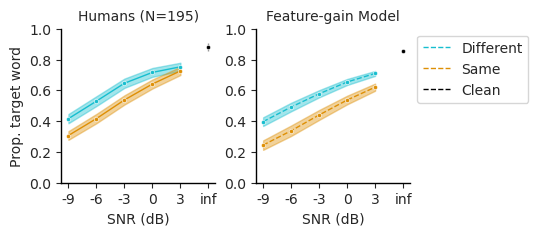

In [56]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = combined_dist_sex_results.copy()
# don't plot baseline 
# to_plot = to_plot[to_plot.group != 'Baseline CNN']
# hue_order = summary_df.sex_cond.unique()
hue_order = ['Different', 'Same', 'Clean']

palette = dict(zip(hue_order[:-1], sns.color_palette(palette='colorblind', n_colors=10, as_cmap=False)))
palette['Clean'] = 'k'
palette['Different'] = 'tab:cyan'

fontsize=10
tick_fontsize = 10
# fontsize = 10

models = to_plot.group.unique()

n_models = len(models)
aspect = 2
fig, axs = plt.subplots(1, 2, figsize=((aspect) * 2.5 , aspect ))

err_band_alpha = 0.4
# add markers to relplot
# models = [f'Humans (N={N})', 'Feature-gain Model', "Baseline CNN"]
x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'

yticks = np.linspace(0,1,6).round(1)
ratio = 1.0 
line_thickness = 1

for ax, model in zip(axs, models):
    sns.lineplot(data=to_plot[to_plot.group == model],  x='snr', y='adjusted_accuracy', hue='sex_cond', hue_order=hue_order,
                  palette=palette, ax=ax,
                  errorbar=('se', 2), err_style='band', err_kws={'alpha':err_band_alpha},
                  marker='.', 
                 )
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('sex_cond'):
        if not group in hue_order:
            continue
        # plot the errorbar with the correct color for each group 
        selected['adj_acc_std_error'] = selected['adj_acc_std_error'] * 2 
        # ax.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette[group], marker=None, ls='none' )
        # add errorbar as fill_between 
        ax.fill_between(selected['snr'], selected['adjusted_accuracy'] - selected['adj_acc_std_error'],
                         selected['adjusted_accuracy'] + selected['adj_acc_std_error'], color=palette[group], alpha=err_band_alpha)

    ax.set_xlabel("SNR (dB)", fontsize=fontsize)
    ax.set_title(model, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_yticks(np.linspace(0,1,6).round(1))
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        if model != f'Humans (N={N})':
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

# remove legend
# g._legend.remove()
sns.despine()
# turn off axs[0] legend 
for ix in range(n_models-1):
    axs[ix].legend().remove()

axs[0].set_ylabel("Prop. target word", fontsize=fontsize)
for ix in range(1, n_models):
    axs[ix].set_ylabel("", fontsize=fontsize)

# move axs[1] legend 
axs[-1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize)

# # set space between pannels 
plt.subplots_adjust(wspace=0.01)

# plt.savefig(outfig_dest/'human_model_save_diff_sex_acc.pdf', transparent=True, bbox_inches='tight')



In [57]:
### get model conf results 
# # combine f0_analysis_df and model_f0_df keeping only columns in both
# model_f0_df['id_subject'] = 'model'
# model_f0_df['group'] = 'model'
all_model_f0_results['id_subject'] = all_model_f0_results['group']
all_model_f0_results.loc[all_model_f0_results.snr == 'inf', 'sex_cond'] = 'Clean'
all_model_f0_results.loc[all_model_f0_results.snr == 'inf', 'dist_lang'] = 'None'


# don't include Baseline CNN in model results
wanted_model_f0_results = all_model_f0_results[all_model_f0_results.group.isin(wanted_models) & (all_model_f0_results.dist_lang == 'English')].copy()

model_dist_df = (wanted_model_f0_results.groupby(["snr", "group", "sex_cond"])
                     .agg({'accuracy':['mean', 'count'],
                            'confusions':['mean'],
                            'adjusted_accuracy':['mean'],
                            'adjusted_confusions':['mean']})
                     .reset_index())

model_dist_df['snr'] = model_dist_df['snr'].replace(np.inf, 6)
model_dist_df['snr'] =  model_dist_df['snr'].replace("inf", 6)
model_dist_df['snr'] = model_dist_df['snr'].astype('int')
# flatten multiindex 
model_dist_df.columns = ['_'.join(col).strip() for col in model_dist_df.columns.values]
# remove trailing underscore
model_dist_df.columns = [col[:-1] if col.endswith('_') else col for col in model_dist_df.columns.values]

# human summary

### Human distractor sex summary 
model_summary_sex_cond_df = model_dist_df.groupby(['snr', 'sex_cond']).agg({'accuracy_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count'],
                                                             'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
model_summary_sex_cond_df.columns = ['snr', 'sex_cond', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']

# add group tag back 
model_summary_sex_cond_df['group'] = 'Feature-gain Model'
model_summary_sex_cond_df

,snr,sex_cond,accuracy,acc_std_error,confusions,conf_std_error,N,adjusted_accuracy,adj_acc_std_error,adjusted_confusions,adj_conf_std_error,group
0,-9,Different,0.301998,0.007519,0.001793,0.000375,8,0.308017,0.007796,0.139728,0.009658,Feature-gain Model
1,-9,Same,0.142674,0.010949,0.386014,0.015508,8,0.148181,0.011314,0.398053,0.015578,Feature-gain Model
2,-6,Different,0.396644,0.010173,0.001921,0.000359,8,0.405866,0.010305,0.091957,0.005945,Feature-gain Model
3,-6,Same,0.224001,0.012064,0.289831,0.011575,8,0.230789,0.012452,0.298924,0.011669,Feature-gain Model
4,-3,Different,0.493340,0.006763,0.001665,0.000579,8,0.505891,0.006796,0.057121,0.004115,Feature-gain Model
5,-3,Same,0.330302,0.013058,0.200435,0.007672,8,0.339139,0.013472,0.207351,0.007856,Feature-gain Model
6,0,Different,0.578637,0.007135,0.001025,0.000335,8,0.593494,0.007355,0.031890,0.001821,Feature-gain Model
7,0,Same,0.437116,0.008824,0.130123,0.004699,8,0.447362,0.008743,0.136655,0.004821,Feature-gain Model
8,3,Different,0.645748,0.007715,0.000256,0.000168,8,0.662526,0.007735,0.021132,0.001448,Feature-gain Model
9,3,Same,0.533940,0.006639,0.074155,0.002710,8,0.547003,0.006490,0.079150,0.003011,Feature-gain Model


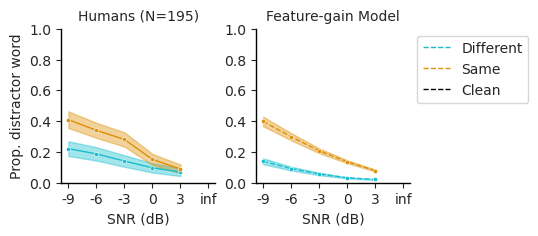

In [58]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = human_dist_df[human_dist_df.dist_lang == 'English']
# to_plot = to_plot[to_plot.group != 'Baseline CNN']

N = int(to_plot.id_subject.nunique())
to_plot = to_plot.groupby(['snr', 'sex_cond']).agg({'correct_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count'],
                                                             'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
to_plot.columns = ['snr', 'sex_cond', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']


## distractor sex 
to_plot['group'] = f'Humans (N={N})'
combined_dist_sex_results_confs = pd.concat([to_plot, model_summary_sex_cond_df], axis=0, ignore_index=True)
combined_dist_sex_results_confs.loc[combined_dist_sex_results_confs.snr == np.inf, 'snr'] = 6
combined_dist_sex_results_confs.loc[combined_dist_sex_results_confs.snr == 'inf', 'snr'] = 6
combined_dist_sex_results_confs.snr = combined_dist_sex_results_confs.snr.astype('int')

# don't plot baseline 
# to_plot = combined_dist_sex_results_confs[combined_dist_sex_results_confs.group != 'Baseline CNN']
to_plot = combined_dist_sex_results_confs.copy()

# hue_order = summary_df.sex_cond.unique()
hue_order = ['Different', 'Same', 'Clean']

palette = dict(zip(hue_order[:-1], sns.color_palette(palette='colorblind', n_colors=10, as_cmap=False)))
palette['Clean'] = 'k'
palette['Different'] = 'tab:cyan'

fontsize=10
tick_fontsize = 10
# fontsize = 10

models = to_plot.group.unique()

n_models = len(models)
aspect = 2
fig, axs = plt.subplots(1, 2, figsize=((aspect) * 2.5 , aspect ))

err_band_alpha = 0.4
# add markers to relplot
# models = [f'Humans (N={N})', 'Feature-gain Model', "Baseline CNN"]
# x_tick_locs = to_plot.snr.unique()
# x_tick_locs = np.append(x_tick_locs, [6])
# x_tick_labels = [str(x) for x in x_tick_locs]
# x_tick_labels[-1] = 'inf'

yticks = np.linspace(0,1,6).round(1)
ratio = 1.0 
line_thickness = 1

for ax, model in zip(axs, models):
    ax.plot(x_tick_locs, np.ones(len(x_tick_locs)) * 0.5, 'w', alpha=0.5, label=None)
    sns.lineplot(data=to_plot[to_plot.group == model],  x='snr', y='adjusted_confusions', hue='sex_cond', hue_order=hue_order,
                  palette=palette, ax=ax,
                  errorbar=('se', 2), err_style='band', err_kws={'alpha':err_band_alpha},
                  marker='.', 
                 )
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('sex_cond'):
        if not group in hue_order:
            continue
        # plot the errorbar with the correct color for each group 
        selected['adj_conf_std_error'] = selected['adj_conf_std_error'] * 2 
        # ax.errorbar(data=selected, x="snr", y="adjusted_confusions", yerr="adj_conf_std_error", color=palette[group], marker=None, ls='none' )
        # add errorbar as fill_between 
        ax.fill_between(selected['snr'], selected['adjusted_confusions'] - selected['adj_conf_std_error'],
                         selected['adjusted_confusions'] + selected['adj_conf_std_error'], color=palette[group], alpha=err_band_alpha)

    ax.set_xlabel("SNR (dB)", fontsize=fontsize)
    ax.set_title(model, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_yticks(np.linspace(0,1,6).round(1))
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        if model !=  f'Humans (N={N})':
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

# remove legend
# g._legend.remove()
# sns.despine()
# # turn off axs[0] legend 
# axs[0].legend().remove()
# axs[1].legend().remove()
# axs[0].set_ylabel("Prop. distractor word", fontsize=fontsize)
# axs[1].set_ylabel("", fontsize=fontsize)
# axs[2].set_ylabel("", fontsize=fontsize)
# # move axs[1] legend 
# axs[2].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize)


sns.despine()
# turn off axs[0] legend 
for ix in range(n_models-1):
    axs[ix].legend().remove()

axs[0].set_ylabel("Prop. distractor word", fontsize=fontsize)
for ix in range(1, n_models):
    axs[ix].set_ylabel("", fontsize=fontsize)

# move axs[1] legend 
axs[-1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize)


# # set space between pannels 
plt.subplots_adjust(wspace=0.01)

# plt.savefig(outfig_dest/'human_model_same_diff_sex_confs.pdf', transparent=True, bbox_inches='tight')



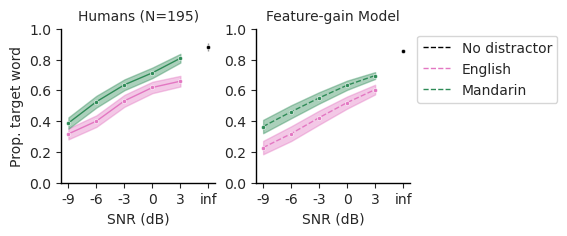

In [61]:
to_plot = combined_dist_lang_results.copy()
# to_plot = to_plot[to_plot.group != 'Baseline CNN']

to_plot.loc[to_plot.dist_lang == 'None', "dist_lang"] = 'No distractor'
to_plot.loc[to_plot.dist_lang.isna(), "dist_lang"] = 'No distractor'

# hue_order = summary_df.dist_lang.unique()
cmap = sns.color_palette("gnuplot2", n_colors=3)

hue_order = ['No distractor','Mandarin' , 'English', 'Dutch',]
hue_plot_order = ['No distractor', 'English', 'Mandarin']
# palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

palette = {lang:cmap[ix] for ix, lang in enumerate(hue_order[1:])}
palette['No distractor'] = 'k'
palette['English'] = 'tab:pink'
palette['Mandarin'] = 'seagreen'
palette['Dutch'] = 'orange'


fontsize=10
tick_fontsize = 10
# fontsize = 10

models = to_plot.group.unique()

# aspect = 3
n_models = len(models)
# fig, axs = plt.subplots(1, n_models, figsize=((n_models) * aspect , aspect ))
aspect = 2
fig, axs = plt.subplots(1, 2, figsize=((aspect) * 2.5 , aspect ))

# aspect = 2
# fig, axs = plt.subplots(1, 3, figsize=((aspect) * 3.5 , aspect ))

err_band_alpha = 0.4
# add markers to relplot
# models = [f'Humans (N={N})', 'Feature-gain Model', 'Baseline CNN']
x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'

yticks = np.linspace(0,1,6).round(1)
ratio = 1.0 
line_thickness = 1

for ax, model in zip(axs, models):
    sns.lineplot(data=to_plot[to_plot.group == model],  x='snr', y='adjusted_accuracy', hue='dist_lang', hue_order=hue_plot_order,
                  palette=palette, ax=ax,
                  errorbar=('se', 2), err_style='band', err_kws={'alpha':err_band_alpha},
                  marker='.', 
                 )
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('dist_lang'):
        if not group in hue_plot_order:
            continue
        # plot the errorbar with the correct color for each group 
        selected['adj_acc_std_error'] = selected['adj_acc_std_error'] * 2 
        # ax.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette[group], marker=None, ls='none' )
        # add errorbar as fill_between 
        ax.fill_between(selected['snr'], selected['adjusted_accuracy'] - selected['adj_acc_std_error'],
                         selected['adjusted_accuracy'] + selected['adj_acc_std_error'], color=palette[group], alpha=err_band_alpha)

    ax.set_xlabel("SNR (dB)", fontsize=fontsize)
    ax.set_title(model, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_yticks(np.linspace(0,1,6).round(1))
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        if model != models[0]:
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')


sns.despine()
# turn off axs[0] legend 
for ix in range(n_models-1):
    axs[ix].legend().remove()

axs[0].set_ylabel("Prop. target word", fontsize=fontsize)
for ix in range(1, n_models):
    axs[ix].set_ylabel("", fontsize=fontsize)

# move axs[1] legend 
axs[-1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize)
# set space between pannels 
plt.subplots_adjust(wspace=0.01)
# plt.savefig(outfig_dest/'human_model_unfamiliar_language.pdf', transparent=True, bbox_inches='tight')



## Combine same/diff sex for scatter plot

In [62]:
combined_dist_sex_results.sex_cond = combined_dist_sex_results.sex_cond.replace({'Different': "Different sex", 'Same': "Same sex"})
combined_dist_sex_results['background_condition'] = combined_dist_sex_results.sex_cond.values 
### Add to combined results 
sex_results_to_merge =  combined_dist_sex_results[['snr', 'background_condition',  'adjusted_accuracy', 'adj_acc_std_error',
       'adjusted_confusions', 'adj_conf_std_error', 'group']].copy().reset_index()
res_for_scatter = pd.concat([human_fba_results, sex_results_to_merge], ignore_index=True)


### Need to adjust same vs different sex confusions to only reflect english talkers 
# get data for confusions 
human_conf_df = human_dist_df[human_dist_df.dist_lang == 'English']
# to_plot = to_plot[to_plot.group != 'Baseline CNN']

N = int(human_conf_df.id_subject.nunique())
human_conf_df = human_conf_df.groupby(['snr', 'sex_cond']).agg({'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
human_conf_df.columns = ['snr', 'sex_cond', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']

## distractor sex 
human_conf_df['group'] = f'Humans (N={N})'
conf_results_df = pd.concat([human_conf_df, all_model_f0_results[all_model_f0_results.dist_lang == 'English']], axis=0, ignore_index=True)
conf_results_df.loc[conf_results_df.snr == np.inf, 'snr'] = 6
conf_results_df.loc[conf_results_df.snr == 'inf', 'snr'] = 6
conf_results_df.snr = conf_results_df.snr.astype('int')
conf_results_df.sex_cond = conf_results_df.sex_cond.replace({'Different': "Different sex", 'Same': "Same sex"})
conf_results_df.background_condition = conf_results_df.sex_cond.values 

## update confusions by snr and sex condition 
conf_results =  conf_results_df[['snr', 'background_condition',
       'adjusted_confusions', 'adj_conf_std_error', 'group']].copy().reset_index(drop=True)
# add one talker results to combined conf results 
conf_results = pd.concat([conf_results, human_fba_results.loc[human_fba_results.background_condition == '1-talker', ['group', 'snr', 'background_condition', 'adjusted_confusions', 'adj_conf_std_error']].reset_index(drop=True)
                     ], ignore_index=True)

## Save human and model results for summary 

In [63]:
model_dist_df

,snr,group,sex_cond,accuracy_mean,accuracy_count,confusions_mean,adjusted_accuracy_mean,adjusted_confusions_mean
0,-9,Feature-gain Model,Different,0.310451,976,0.002049,0.318648,0.159836
1,-9,Feature-gain Model,Same,0.168033,976,0.425205,0.173156,0.438525
2,-9,word_task_v09_4MGB_ln_first_arch_1,Different,0.305328,976,0.003074,0.310451,0.134221
3,-9,word_task_v09_4MGB_ln_first_arch_1,Same,0.115779,976,0.402664,0.119877,0.412910
4,-9,word_task_v09_4MGB_ln_first_arch_2,Different,0.308402,976,0.002049,0.318648,0.109631
...,...,...,...,...,...,...,...,...
75,3,word_task_v09_4MGB_ln_first_arch_7,Same,0.558402,976,0.071721,0.569672,0.076844
76,3,word_task_v09_4MGB_ln_first_arch_8,Different,0.630123,976,0.000000,0.648566,0.028689
77,3,word_task_v09_4MGB_ln_first_arch_8,Same,0.537910,976,0.072746,0.553279,0.075820
78,3,word_task_v09_4MGB_ln_first_arch_9,Different,0.637295,976,0.001025,0.654713,0.016393


In [64]:
# model_l

In [65]:
## Save pre-combined model results - will be used for bootstrap
out_dir = Path("final_results_dir")
out_dir.mkdir(parents=True, exist_ok=True)

# summary_df.to_pickle(out_dir / "summary_2024_SWC_diotic_participant_results.pdpkl")
# models_summary_df.to_pickle(out_dir / "summary_2024_SWC_diotic_model_results.pdpkl")

## Make scatter plots

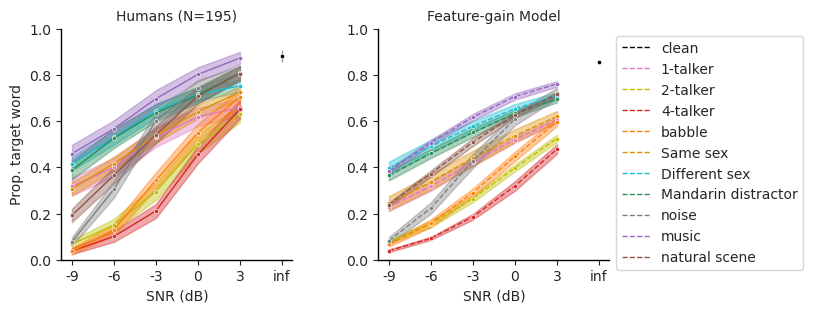

In [66]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = res_for_scatter[(~res_for_scatter.background_condition.isin(["catch_trial", 'audioset']))  ]
# to_plot = combined_results[(~combined_results.background_condition.isin(["catch_trial", 'audioset']))  ]
sns.set_style('ticks')



hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble', 'Same sex', 'Different sex', 'Mandarin distractor', 'noise', 'music', 'natural scene']
# hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble',  'noise',  'music', 'natural scene']
palette={}
palette['clean'] = 'k'
palette['1-talker'] = 'tab:pink'
palette['2-talker'] = 'y'
palette['babble'] = 'tab:orange'
palette['4-talker'] = 'tab:red'
palette['noise'] = 'grey'
palette['music'] = 'tab:purple'
palette['natural scene'] = 'tab:brown'
# add same vs different sex 
sex_order = ['Different sex', 'Same sex']
sex_palette = dict(zip(sex_order, sns.color_palette(palette='colorblind', n_colors=10, as_cmap=False)))
palette['Same sex'] = sex_palette['Same sex']
palette['Different sex'] = 'tab:cyan'
# add language distractors
## add language distractors 
palette['Mandarin distractor'] =  'seagreen'
# palette['Dutch distractor'] =  cmap[2]


fontsize=10
tick_fontsize = 10
# fontsize = 10

aspect = 3
models = [f'Humans (N={N})', 'Feature-gain Model']
fig, axs = plt.subplots(1, len(models), figsize=((aspect * len(models) ) * 1.25 , aspect ))

err_band_alpha = 0.4
# add markers to relplot
x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'

yticks = np.linspace(0,1,6).round(1)
ratio = 1.0 
line_thickness = 1

for ax, model in zip(axs, models):
    sns.lineplot(data=to_plot[to_plot.group == model],  x='snr', y='adjusted_accuracy', hue='background_condition', hue_order=hue_order,
                  palette=palette, ax=ax,
                  errorbar=('se', 2), err_style='band', err_kws={'alpha':err_band_alpha},
                  marker='.', 
                 )
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        if not group in hue_order:
            continue
        # plot the errorbar with the correct color for each group 
        selected['adj_acc_std_error'] = selected['adj_acc_std_error'] * 2 
        # ax.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette[group], marker=None, ls='none' )
        # add errorbar as fill_between 
        ax.fill_between(selected['snr'], selected['adjusted_accuracy'] - selected['adj_acc_std_error'],
                         selected['adjusted_accuracy'] + selected['adj_acc_std_error'], color=palette[group], alpha=err_band_alpha)

    ax.set_xlabel("SNR (dB)", fontsize=fontsize)
    ax.set_title(model, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_yticks(np.linspace(0,1,6).round(1))
    ax.set_xticks(x_tick_locs)
    ax.set_xticklabels(x_tick_labels)
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for line in ax.get_lines():
    #     line.set_markerfacecolor(line.get_color())
    #     line.set_markeredgecolor('w')
        line.set_linewidth(1)
        line.set_markersize(6)
        line.set_markeredgewidth(.4)
        if model != f'Humans (N={N})':
            line.set_linestyle('--')

    # set line thickness for pannel
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

# remove legend
# g._legend.remove()
sns.despine()
# turn off axs[0] legend 
for ax in axs[:-1]:
    ax.legend().remove()
# axs[0].legend().remove()
axs[0].set_ylabel("Prop. target word", fontsize=fontsize)
axs[1].set_ylabel("", fontsize=fontsize)
axs[1].set_ylabel("", fontsize=fontsize)

# move axs[1] legend 
axs[1].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=fontsize)


# adjust w space 
# 
# plt.savefig(outfig_dest/'human_v_model_acc_for_poster_all_conds.pdf', transparent=True, bbox_inches='tight')


## Make scatter plots 


/tmp/ipykernel_2476742/3411145076.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df.sort_values(['snr', 'background_condition'], inplace=True)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


clean [0.0086507]
1-talker [0.01727186 0.01988729 0.01724905 0.01348672 0.01309112]
2-talker [0.00872622 0.01422352 0.01534902 0.01460554 0.01616051]
babble [0.00930177 0.01712717 0.01838536 0.0203373  0.01850123]
4-talker [0.00601109 0.00660543 0.01230689 0.0206122  0.02074976]
noise [0.01550486 0.02469495 0.03052412 0.02748701 0.02296264]
music [0.01061258 0.01197218 0.01413328 0.0135979  0.01207314]
natural scene [0.00867667 0.01376676 0.01707784 0.01180941 0.00944179]
Same sex [0.0308689  0.0339574  0.03226647 0.0280476  0.0232523 ]
Different sex [0.02819586 0.02785164 0.02334682 0.0195607  0.01610639]
Mandarin distractor [0.02139358 0.02016513 0.01939335 0.01577804 0.01513029]


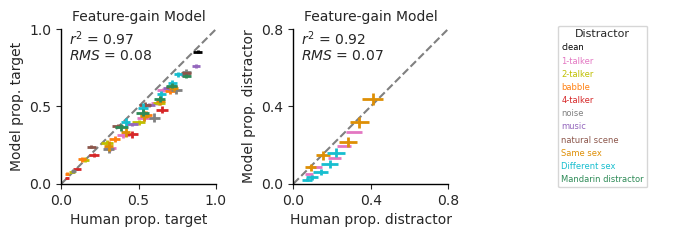

In [70]:
# to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]
to_plot = res_for_scatter[~res_for_scatter.background_condition.isin(["catch_trial", 'audioset']) & (res_for_scatter.background_condition != 'Dutch distractor')].copy()


# hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble',  'Dutch distractor', 'Mandarin distractor', 'noise', 'music', 'natural scene']
hue_order = ['clean', '1-talker',  '2-talker',  '4-talker', 'babble', 'Same sex',  'Mandarin distractor', 'noise', 'music', 'natural scene', 'Different sex',]

palette={}
palette['clean'] = 'k'
palette['1-talker'] = 'tab:pink'
palette['2-talker'] = 'y'
palette['babble'] = 'tab:orange'
palette['4-talker'] = 'tab:red'
palette['noise'] = 'grey'
palette['music'] = 'tab:purple'
palette['natural scene'] = 'tab:brown'
# add same vs different sex 
sex_order = ['Different sex', 'Same sex']
sex_palette = dict(zip(sex_order, sns.color_palette(palette='colorblind', n_colors=10, as_cmap=False)))
palette['Same sex'] = sex_palette['Same sex']
palette['Different sex'] = 'tab:cyan'
# add language distractors
## add language distractors 
palette['Mandarin distractor'] =  'seagreen'


hue_order = list(palette.keys())

x = y = np.linspace(0,1,5)

human_str = f"Humans (N={N})"
# model_list = ['Feature-gain Model', 'Baseline CNN']
model_list = res_for_scatter.group.unique()[1:]

fontsize = 10

aspect = 3
# fig, axs = plt.subplots(2, 1 + len(model_list), figsize=((aspect * len(model_list) + 1 ) , aspect*2 ))
fig, axs = plt.subplots(1, 3, figsize=(aspect * 2 + 1 , (aspect ) ))
acc_axs = axs[0]
conf_axs = axs[1]
leg_axs = axs[2]

line_width=2
# for ix, group in enumerate(to_plot.group.unique()):
# add dashed line to each subplot 
for i in range(2):
    # for j in range(1 + len(model_list)):
        # if j != len(model_list):
    axs[i].plot(x,y, ls='dashed', color='grey')

human_df = to_plot[to_plot.group == human_str].sort_values(['snr', 'background_condition']).copy()
human_acc_means_full = human_df["adjusted_accuracy"].values
# get confusion data
confusion_conditions = ['1-talker', 'Same sex', "Different sex"]
human_conf_df = conf_results[conf_results.group == human_str].sort_values(['snr', 'background_condition']).copy()
human_conf_means_full = human_conf_df.adjusted_confusions.values

## for R^2, precompute SST for humans 
# SST_acc = np.sum((human_acc_means_full - np.mean(human_acc_means_full))**2)
# SST_conf = np.sum((human_conf_means_full - np.mean(human_conf_means_full))**2)


for ix, model in enumerate(model_list):

    model_df = to_plot[to_plot.group == model]
    # summarize model data
    # model_df = model_df.groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem',], 'confusions':['mean', 'sem'], 
    #                                                                     'adjusted_accuracy': ['mean', 'sem',], 'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
    # rename columns
    # model_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', 'N']
    model_df.sort_values(['snr', 'background_condition'], inplace=True)   
    for condition in hue_order:
        # plot acc 
        human_data = human_df[human_df.background_condition == condition]
        human_means = human_data["adjusted_accuracy"].values
        human_errors = human_data["adj_acc_std_error"].values * 2 # 95% CI

        model_data = model_df[model_df.background_condition == condition]
        model_means = model_data["adjusted_accuracy"].values
        model_errors = model_data["adj_acc_std_error"].values * 2 # 95% CI
        print(condition, model_errors)
        acc_axs.errorbar(x=human_means, y=model_means, xerr=human_errors, yerr=model_errors, marker='',
                         linestyle='', ms=3, elinewidth=line_width, label= condition,
                            color=palette[condition])#, mfc=palette[condition], mec=palette[condition])

    model_conf_df = conf_results[conf_results.group == model]
    model_conf_df = model_conf_df.groupby(['snr', 'background_condition']).agg({'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
    # rename columns
    model_conf_df.columns = ['snr', 'background_condition', 'adjusted_confusions', 'adj_conf_std_error', 'N']
    model_conf_df.sort_values(['snr', 'background_condition'], inplace=True)
    # model confusions
    for condition in confusion_conditions:
        try:
            human_conf_data = human_conf_df[human_conf_df.background_condition == condition]
            human_conf_means = human_conf_data["adjusted_confusions"].values
            human_conf_errors = human_conf_data["adj_conf_std_error"].values * 2 # 95% CI
                
            model_conf_data = model_conf_df[model_conf_df.background_condition ==  condition]
            model_conf_means = model_conf_data["adjusted_confusions"].values
            model_conf_errors = model_conf_data["adj_conf_std_error"].values * 2 # 95% CI 
    
            conf_axs.errorbar(x=human_conf_means, y=model_conf_means, xerr=human_conf_errors, yerr=model_conf_errors, marker='',
                                linestyle='', ms=3, elinewidth=line_width, label= condition,
                                color=palette[condition])
        except:
            continue
    
    # Add error annotations 
    # # acc errors 
    # res = stats.spearmanr(human_df["accuracy"].values,  model_df['accuracy'].values)
    # rho = res.statistic
    # acc_axs.annotate(f"$\\rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)
    # try:
    r, p = stats.pearsonr(human_acc_means_full,  model_df['adjusted_accuracy'].values)
    # spearman_brown_r = r / np.sqrt(human_rho_acc)
    # model_sse_acc = np.sum((human_acc_means_full - model_df['adjusted_accuracy'].values)**2)
    # r_squared = 1 - (model_sse_acc / SST_acc) 
    # acc_axs.annotate(f"$R^2$ = {r_squared:.2f}", (0.05, 0.85), fontsize=fontsize)
    acc_axs.annotate(f"$r^2$ = {r**2:.2f}", (0.05, 0.9), fontsize=fontsize)
    samp_rmse = np.sqrt(np.mean((human_acc_means_full - model_df['adjusted_accuracy'].values)**2))
    acc_axs.annotate(f"$RMS$ = {samp_rmse:.2f}", (0.05, 0.8), fontsize=fontsize)

    # conf errors
    # res = stats.spearmanr(human_conf_means, model_conf_means)
    # rho = res.statistic
    # conf_axs.annotate(f"$\\rho$ = {rho:.2f}", (0.3, 0.11), fontsize=fontsize)
    model_conf_values = model_conf_df['adjusted_confusions'].values
    # model_sse_conf = np.sum((human_conf_means_full - model_conf_values)**2)
    # r_squared = 1 - (model_sse_conf / SST_conf)
    r, p = stats.pearsonr(human_conf_means_full, model_conf_values)
    # spearman_brown_r = r / np.sqrt(human_rho_conf)
    # conf_axs.annotate(f"$R^2$ = {r_squared:.2f}", (0.04, 0.68), fontsize=fontsize)   # old xy coords ( 0.25, 0.05)
    conf_axs.annotate(f"$r^2$ = {r**2:.2f}", (0.04, 0.72), fontsize=fontsize)   # old xy coords ( 0.25, 0.05)
    samp_rmse = np.sqrt(np.mean((human_conf_means - model_conf_means)**2))
    conf_axs.annotate(f"$RMS$ = {samp_rmse:.2f}", (0.04, 0.64), fontsize=fontsize) # old xy coords ( 0.25, 0.025)
    # except:
    #     continue
    # add tiles 
    acc_axs.set_title(model, fontsize=fontsize)
    conf_axs.set_title(model, fontsize=fontsize)
    acc_axs.set_xlabel(f"Human prop. target", fontsize=fontsize)
    conf_axs.set_xlabel(f"Human prop. distractor", fontsize=fontsize)

    
# set first row x and y limits to 0 1
ticks = np.linspace(0,1,3).round(1)

for ax in [acc_axs]:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,1)
    ax.set_xlim(0,1)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')


ticks = np.linspace(0,.8,3).round(1)

for ax in [conf_axs]:
    ax.set_xticks(ticks=ticks) # set new labels
    ax.set_xticklabels(labels=ticks,fontsize=fontsize) 
    ax.set_yticks(ticks=ticks) # set new labels
    ax.set_yticklabels(labels= ticks, fontsize=fontsize)
    ax.set_ylim(0,.8)
    ax.set_xlim(0,.8)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color('k')


    
acc_axs.set_ylabel(f"Model prop. target", fontsize=fontsize)
conf_axs.set_ylabel(f"Model prop. distractor", fontsize=fontsize)


sns.despine()
# lines_labels = [ax.get_legend_handles_labels() for ax in [acc_axs[0]]]
# lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(wspace=0.5)


for ax in axs.flat:
    ax.set(aspect='equal')

# # move axs[1] to left 

# pos = acc_axs[1].get_position()
# pos.x0 -= 0.025
# acc_axs[1].set_position(pos)

# # move axs[3] to left 
# pos = conf_axs[1].get_position()
# pos.x0 -= 0.025
# conf_axs[1].set_position(pos)

## add legend 
handles, labels = axs[0].get_legend_handles_labels()

# axs[0,-1].axis('off')
leg_axs.axis('off')
legend = leg_axs.legend([axs[1].plot([],[])[0] for _ in   labels], labels,
                fancybox=True,
                handlelength=0, handleheight=0, handletextpad=0,
                title='Distractor', 
                title_fontsize=fontsize-2, fontsize=fontsize-4, ncol=1, loc='center')

for text in legend.get_texts():
    text.set_color(palette[text.get_text()])
for item in legend.legendHandles:
    item.set_visible(False)
leg_axs.set_box_aspect(1)
# plt.suptitle(model, y=0.9)
plt.tight_layout()
# plt.savefig(outfig_dest/'human_model_var_exp_scatters.pdf', transparent=True, bbox_inches='tight')
# 